## COMPAS Recidivism Racial Bias
Racial Bias in inmate COMPAS reoffense risk scores
Dataset....[Link](https://www.kaggle.com/datasets/danofer/compass)

*COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) is a widely utilized commercial algorithm employed by judges and parole officers to assess the probability of reoffending (recidivism) among criminal defendants. Research has revealed a bias in the algorithm's outcomes, favoring white defendants over black inmates. This bias was evidenced through a two-year follow-up study, which examined whether individuals actually committed crimes or violent offenses during that period. The discernible pattern of errors, as gauged by precision and sensitivity metrics, is particularly noteworthy.*

In [1]:
#This is to import the library needed while some will be needed in the project.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
label_encoder = LabelEncoder()
scaler = StandardScaler()
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
# import pandas as pd
df_violent_parsed = pd.read_csv("/kaggle/input/compass/cox-violent-parsed.csv")

In [3]:
#This line of code displays the number of features(columns) and observations(rows) in the dataset
row,column=df_violent_parsed.shape
print(f"The df_violent_parsed dataset contain {row} rows and {column} columns")

The df_violent_parsed dataset contain 18316 rows and 52 columns


In [4]:
# Checking the first 5 rows of the dataset
print (type(df_violent_parsed))
df_violent_parsed.head()

<class 'pandas.core.frame.DataFrame'>


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event
0,1.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,13/08/2013 6:03,14/08/2013 5:41,13011352CF10A,13/08/2013,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,0,327,0
1,2.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,13/08/2013 6:03,14/08/2013 5:41,13011352CF10A,13/08/2013,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,334,961,0
2,3.0,michael ryan,michael,ryan,31/12/2014,Male,06/02/1985,31,25 - 45,Caucasian,0,5,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,31/12/2014,30/12/2014,03/01/2015,0,3,457,0
3,4.0,kevon dixon,kevon,dixon,27/01/2013,Male,22/01/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,26/01/2013 3:45,05/02/2013 5:36,13001275CF10A,26/01/2013,NaN,1.0,(F3),Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,05/07/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),05/07/2013,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,27/01/2013,26/01/2013,05/02/2013,0,9,159,1
4,5.0,ed philo,ed,philo,14/04/2013,Male,14/05/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,13/04/2013 4:58,14/04/2013 7:02,13005330CF10A,13/04/2013,NaN,1.0,(F3),Possession of Cocaine,1,13011511MM10A,(M1),0.0,16/06/2013,Driving Under The Influence,16/06/2013,16/06/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,14/04/2013,16/06/2013,16/06/2013,4,0,63,0


In [5]:
# we see an overview where we see the type of data in each column, if there is Nan, the memory usage, etc.
df_violent_parsed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       11001 non-null  float64
 1   name                     18316 non-null  object 
 2   first                    18316 non-null  object 
 3   last                     18316 non-null  object 
 4   compas_screening_date    18316 non-null  object 
 5   sex                      18316 non-null  object 
 6   dob                      18316 non-null  object 
 7   age                      18316 non-null  int64  
 8   age_cat                  18316 non-null  object 
 9   race                     18316 non-null  object 
 10  juv_fel_count            18316 non-null  int64  
 11  decile_score             18316 non-null  int64  
 12  juv_misd_count           18316 non-null  int64  
 13  juv_other_count          18316 non-null  int64  
 14  priors_count          

In [6]:
# Checking for missing values
df_violent_parsed.isnull().sum()

id                          7315
name                           0
first                          0
last                           0
compas_screening_date          0
sex                            0
dob                            0
age                            0
age_cat                        0
race                           0
juv_fel_count                  0
decile_score                   0
juv_misd_count                 0
juv_other_count                0
priors_count                   0
days_b_screening_arrest     1297
c_jail_in                   1297
c_jail_out                  1297
c_case_number                867
c_offense_date              3952
c_arrest_date              15231
c_days_from_compas           867
c_charge_degree              867
c_charge_desc                881
is_recid                       0
r_case_number               9899
r_charge_degree             9899
r_days_from_arrest         11957
r_offense_date              9899
r_charge_desc              10039
r_jail_in 

In [7]:
# Checking for the top five and the last five rows of the dataset
df_violent_parsed

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event
0,1.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,13/08/2013 6:03,14/08/2013 5:41,13011352CF10A,13/08/2013,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,0,327,0
1,2.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,13/08/2013 6:03,14/08/2013 5:41,13011352CF10A,13/08/2013,NaN,1.0,(F3),Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,334,961,0
2,3.0,michael ryan,michael,ryan,31/12/2014,Male,06/02/1985,31,25 - 45,Caucasian,0,5,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,31/12/2014,30/12/2014,03/01/2015,0,3,457,0
3,4.0,kevon dixon,kevon,dixon,27/01/2013,Male,22/01/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,26/01/2013 3:45,05/02/2013 5:36,13001275CF10A,26/01/2013,NaN,1.0,(F3),Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,05/07/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),05/07/2013,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,27/01/2013,26/01/2013,05/02/2013,0,9,159,1
4,5.0,ed philo,ed,philo,14/04/2013,Male,14/05/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,13/04/2013 4:58,14/04/2013 7:02,13005330CF10A,13/04/2013,NaN,1.0,(F3),Possession of Cocaine,1,13011511MM10A,(M1),0.0,16/06/2013,Driving Under The Influence,16/06/2013,16/06/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,14/04/2013,16/06/2013,16/06/2013,4,0,63,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18311,NaN,alexsandra beauchamps,alexsandra,beauchamps,29/12/2014,Female,21/12/1984,31,25 - 45,African-American,0,6,0,0,5,-1.0,28/12/2014 10:14,07/01/2015 11:42,14018106MM10A,28/12/2014,NaN,1.0,(M1),Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,29/12/2014,Risk of Violence,4,Low,29/12/2014,28/12/2014,07/01/2015,5,9,459,0
18312,NaN,winston gregory,winston,gregory,14/01/2014,Male,01/10/1958,57,Greater than 45,Other,0,1,0,0,0,-1.0,13/01/2014 5:48,14/01/2014 7:49,14000581CF10A,13/01/2014,NaN,1.0,(F2),Aggravated Battery / Pregnant,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,14/01/2014,Risk of Violence,1,Low,14/01/2014,13/01/2014,14/01/2014,0,0,808,0
18313,NaN,farrah jean,farrah,jean,09/03/2014,Female,17/11/1982,33,25 - 45,African-American,0,2,0,0,3,-1.0,08/03/2014 8:06,09/03/2014 12:18,14003308CF10A,08/03/2014,NaN,1.0,(M1),Battery on Law Enforc Officer,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,2,Low,09/03/2014,Risk of Violence,2,Low,09/03/2014,08/03/2014,09/03/2014,3,0,754,0
18314,NaN,florencia sanmartin,florencia,sanmartin,30/06/2014,Female,18/12/1992,23,Less than 25,Hispanic,0,4,0,0,2,-2.0,28/06/2014 12:16,30/06/2014 11:19,14008895CF10A,28/06/2014,NaN,2.0,(F3),Possessi

In [8]:
# Drop variables that are not needed
columns_to_drop = ['id', 'first', 'last', 'in_custody', 'vr_charge_desc', 'r_case_number', 'vr_charge_degree', 
                   'c_offense_date', 'c_case_number', 'r_offense_date', 'juv_other_count', 'end', 'event', 
                   'screening_date', 'start', 'juv_misd_count', 'juv_fel_count', 'r_days_from_arrest', 
                   'r_charge_degree', 'days_b_screening_arrest', 'vr_case_number', 'priors_count.1', 'r_jail_out', 
                   'c_arrest_date', 'r_charge_desc', 'r_jail_in', 'violent_recid', 'decile_score.1', 
                   'vr_offense_date', 'out_custody']

df_violent_parsed.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')


In [9]:
# Checking to confirm the drop columns has been droped
df_violent_parsed

,name,compas_screening_date,sex,dob,age,age_cat,race,decile_score,priors_count,c_jail_in,c_jail_out,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,is_violent_recid,type_of_assessment,score_text,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date
0,miguel hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,1,0,13/08/2013 6:03,14/08/2013 5:41,1.0,(F3),Aggravated Assault w/Firearm,0,0,Risk of Recidivism,Low,Risk of Violence,1,Low,14/08/2013
1,miguel hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,1,0,13/08/2013 6:03,14/08/2013 5:41,1.0,(F3),Aggravated Assault w/Firearm,0,0,Risk of Recidivism,Low,Risk of Violence,1,Low,14/08/2013
2,michael ryan,31/12/2014,Male,06/02/1985,31,25 - 45,Caucasian,5,0,NaN,NaN,NaN,NaN,NaN,-1,0,Risk of Recidivism,Medium,Risk of Violence,2,Low,31/12/2014
3,kevon dixon,27/01/2013,Male,22/01/1982,34,25 - 45,African-American,3,0,26/01/2013 3:45,05/02/2013 5:36,1.0,(F3),Felony Battery w/Prior Convict,1,1,Risk of Recidivism,Low,Risk of Violence,1,Low,27/01/2013
4,ed philo,14/04/2013,Male,14/05/1991,24,Less than 25,African-American,4,4,13/04/2013 4:58,14/04/2013 7:02,1.0,(F3),Possession of Cocaine,1,0,Risk of Recidivism,Low,Risk of Violence,3,Low,14/04/2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18311,alexsandra beauchamps,29/12/2014,Female,21/12/1984,31,25 - 45,African-American,6,5,28/12/2014 10:14,07/01/2015 11:42,1.0,(M1),Battery,0,0,Risk of Recidivism,Medium,Risk of Violence,4,Low,29/12/2014
18312,winston gregory,14/01/2014,Male,01/10/1958,57,Greater than 45,Other,1,0,13/01/2014 5:48,14/01/2014 7:49,1.0,(F2),Aggravated Battery / Pregnant,0,0,Risk of Recidivism,Low,Risk of Violence,1,Low,14/01/2014
18313,farrah jean,09/03/2014,Female,17/11/1982,33,25 - 45,African-American,2,3,08/03/2014 8:06,09/03/2014 12:18,1.0,(M1),Battery on Law Enforc Officer,0,0,Risk of Recidivism,Low,Risk of Violence,2,Low,09/03/2014
18314,florencia sanmartin,30/06/2014,Female,18/12/1992,23,Less than 25,Hispanic,4,2,28/06/2014 12:16,30/06/2014 11:19,2.0,(F3),Possession of Ethylone,1,0,Risk of Recidivism,Low,Risk of Violence,4,Low,30/06/2014


### Exploratory Data Analysis (EDA)

In [10]:
#This is to change the data type from object to date

df_violent_parsed['c_jail_in'] = pd.to_datetime(df_violent_parsed['c_jail_in'])
df_violent_parsed['c_jail_out'] = pd.to_datetime(df_violent_parsed['c_jail_out'])
df_violent_parsed['compas_screening_date'] = pd.to_datetime(df_violent_parsed['compas_screening_date'])
df_violent_parsed['v_screening_date'] = pd.to_datetime(df_violent_parsed['v_screening_date'])
df_violent_parsed['days_in_jail'] = abs((df_violent_parsed['c_jail_out'] - df_violent_parsed['c_jail_in']).dt.days)

In [11]:
#This info() will show the information about the sets incuding column name, count and data type

df_violent_parsed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   name                   18316 non-null  object        
 1   compas_screening_date  18316 non-null  datetime64[ns]
 2   sex                    18316 non-null  object        
 3   dob                    18316 non-null  object        
 4   age                    18316 non-null  int64         
 5   age_cat                18316 non-null  object        
 6   race                   18316 non-null  object        
 7   decile_score           18316 non-null  int64         
 8   priors_count           18316 non-null  int64         
 9   c_jail_in              17019 non-null  datetime64[ns]
 10  c_jail_out             17019 non-null  datetime64[ns]
 11  c_days_from_compas     17449 non-null  float64       
 12  c_charge_degree        17449 non-null  object        
 13  c

In [12]:
# data.isnull().sum() to get the number of missing records in each column

print("The sum of Null values in each columns ")

df_violent_parsed.isnull().sum()

The sum of Null values in each columns 


name                        0
compas_screening_date       0
sex                         0
dob                         0
age                         0
age_cat                     0
race                        0
decile_score                0
priors_count                0
c_jail_in                1297
c_jail_out               1297
c_days_from_compas        867
c_charge_degree           867
c_charge_desc             881
is_recid                    0
is_violent_recid            0
type_of_assessment          0
score_text                 23
v_type_of_assessment        0
v_decile_score              0
v_score_text                6
v_screening_date            0
days_in_jail             1297
dtype: int64

In [13]:
# Impute missing values for numerical variables
numeric_cols = ['c_days_from_compas', 'v_decile_score',]
for col in numeric_cols:
    df_violent_parsed[col].fillna(df_violent_parsed[col].median(), inplace=True)

# Impute missing values for categorical variables
categorical_cols = ['c_charge_degree', 'score_text', 'v_score_text', 'c_jail_in', 'c_jail_out', 'c_charge_desc', 'days_in_jail']
for col in categorical_cols:
    df_violent_parsed[col].fillna(df_violent_parsed[col].mode()[0], inplace=True)

# Checking for any missing values remaining
print(df_violent_parsed.isnull().sum())

name                     0
compas_screening_date    0
sex                      0
dob                      0
age                      0
age_cat                  0
race                     0
decile_score             0
priors_count             0
c_jail_in                0
c_jail_out               0
c_days_from_compas       0
c_charge_degree          0
c_charge_desc            0
is_recid                 0
is_violent_recid         0
type_of_assessment       0
score_text               0
v_type_of_assessment     0
v_decile_score           0
v_score_text             0
v_screening_date         0
days_in_jail             0
dtype: int64


In [14]:
#A statistics summary of all data, excluding object, category etc

df_violent_parsed.describe()

,compas_screening_date,age,decile_score,priors_count,c_jail_in,c_jail_out,c_days_from_compas,is_recid,is_violent_recid,v_decile_score,v_screening_date,days_in_jail
count,18316,18316.000000,18316.000000,18316.000000,18316,18316,18316.000000,18316.000000,18316.000000,18316.000000,18316,18316.000000
mean,2013-11-22 23:28:18.973574912,34.019273,4.997052,3.913191,2013-11-06 20:46:19.209434624,2013-12-06 14:03:25.459707392,55.010919,0.414774,0.073105,4.022822,2013-11-22 23:28:18.973574912,23.293514
min,2013-01-01 00:00:00,18.000000,-1.000000,0.000000,2013-01-01 01:31:00,2013-01-02 01:12:00,0.000000,-1.000000,0.000000,-1.000000,2013-01-01 00:00:00,0.000000
25%,2013-04-22 00:00:00,25.000000,2.000000,0.000000,2013-03-30 01:04:00,2013-04-30 07:29:00,1.000000,0.000000,0.000000,2.000000,2013-04-22 00:00:00,0.000000
50%,2013-11-08 00:00:00,31.000000,5.000000,2.000000,2013-10-18 01:38:00,2013-11-13 01:00:00,1.000000,0.000000,0.000000,4.000000,2013-11-08 00:00:00,1.000000
75%,2014-05-29 00:00:00,41.000000,8.000000,5.000000,2014-05-15 10:48:00,2014-06-10 07:35:00,2.000000,1.000000,0.000000,6.000000,2014-05-29 00:00:00,14.000000
max,2014-12-31 00:00:00,96.000000,10.000000,43.000000,2016-03-11 10:26:00,2020-01-01 00:00:00,9485.000000,1.000000,1.000000,10.000000,2014-12-31 00:00:00,2152.000000
std,NaN,11.667811,2.937569,5.299864,NaN,NaN,310.610219,0.576449,0.260317,2.614189,NaN,64.917074


### EDA
#### After making the appropriate corrections and keeping the columns that interest us the most, we are going to make an exploratory analysis of the data:

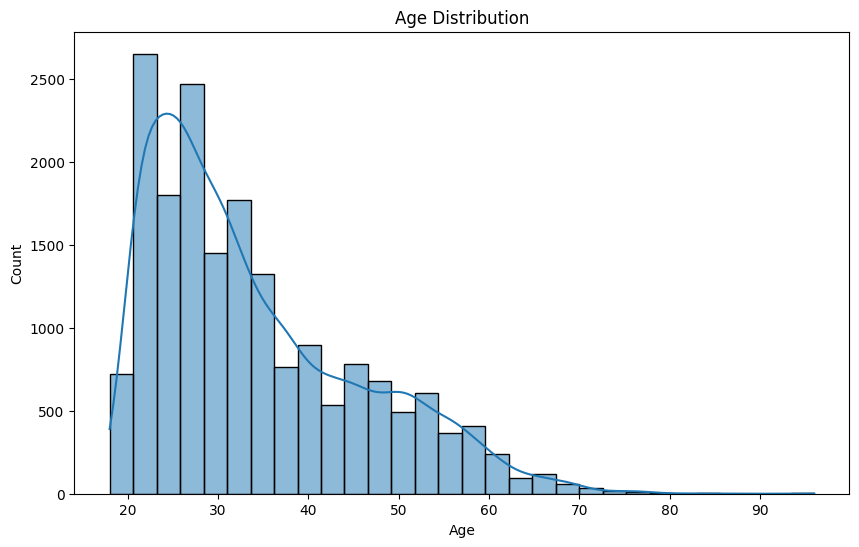

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df_violent_parsed, x='age', bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

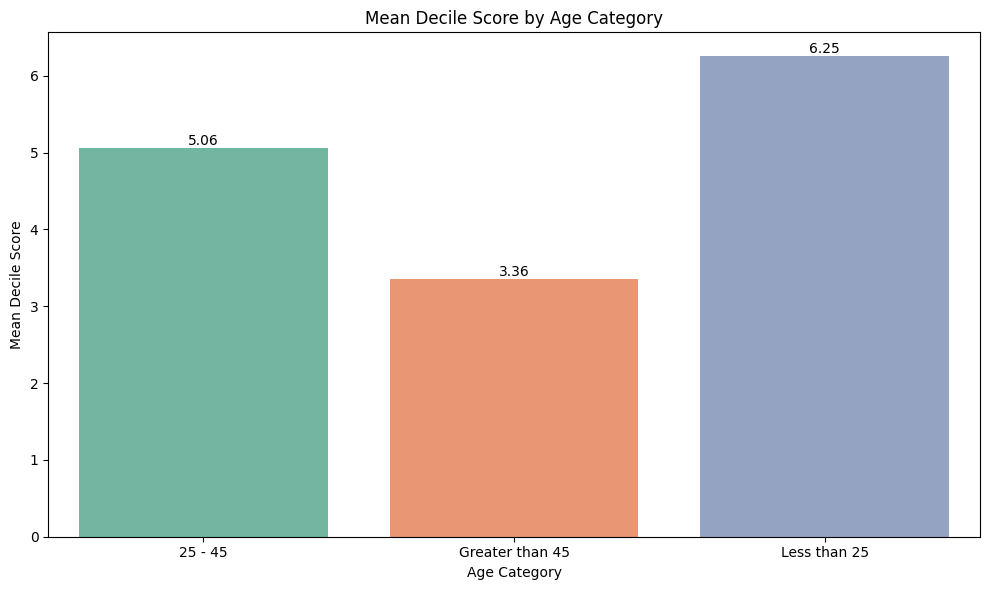

In [16]:
# Plot bar mean decile score of age range
decile_mean_age = df_violent_parsed.groupby("age_cat")["decile_score"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=decile_mean_age, x="age_cat", y="decile_score", 
            palette="Set2")

plt.ylabel("Mean Decile Score")
plt.xlabel("Age Category")
plt.title("Mean Decile Score by Age Category")

# Add percentage labels to each bar
for index, row in decile_mean_age.iterrows():
    plt.text(index, row['decile_score'], f"{row['decile_score']:.2f}", 
             color='black', ha="center", va="bottom")

plt.xticks()  # x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlapping labels
plt.show()

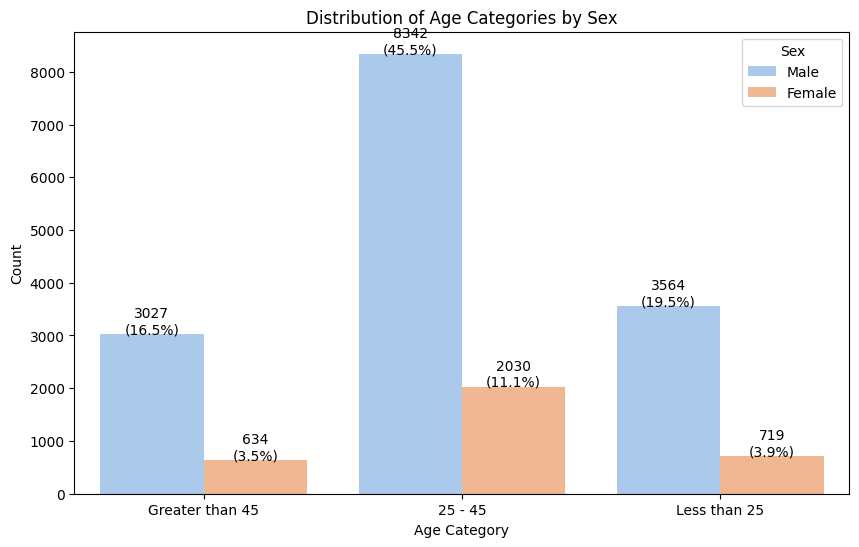

In [17]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='age_cat', hue='sex', data=df_violent_parsed, palette='pastel')
plt.title('Distribution of Age Categories by Sex')
plt.xlabel('Age Category')
plt.ylabel('Count')

# Add percentage labels to each bar
total_counts = df_violent_parsed.groupby(['age_cat', 'sex']).size().reset_index(name='total_count')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, 
            f'{int(height)}\n({100 * height / total_counts["total_count"].sum():.1f}%)', ha="center")

plt.xticks()
plt.legend(title='Sex')
plt.show()

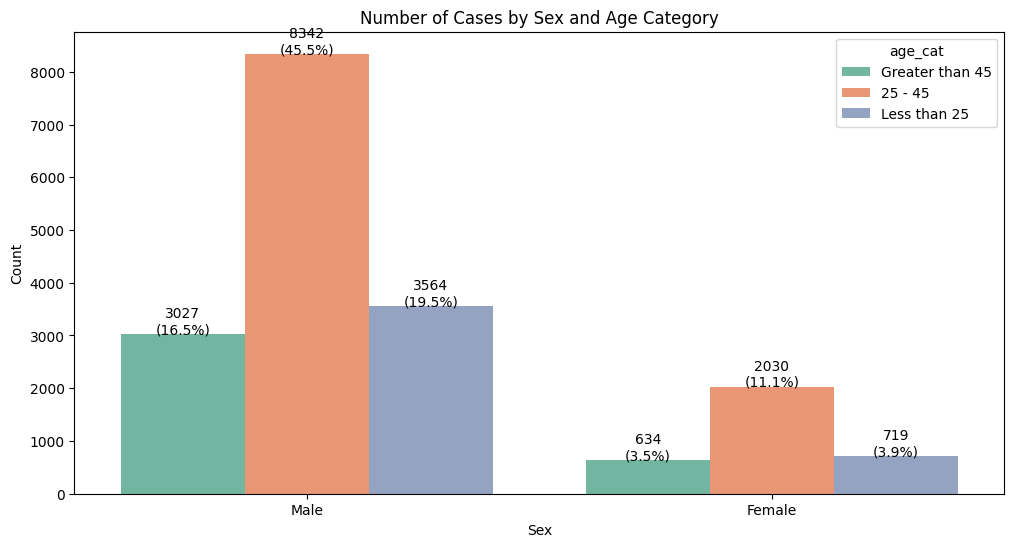

In [18]:
plt.figure(figsize=(12, 6)) 
ax = sns.countplot(data=df_violent_parsed, x="sex", hue="age_cat", palette="Set2") 
plt.title("Number of Cases by Sex and Age Category") 
plt.xlabel("Sex") 
plt.ylabel("Count")  # Add y-axis label

# Calculate total count for each category
total_counts = df_violent_parsed.groupby(['sex', 'age_cat']).size().reset_index(name='total_count')

# Add percentage labels to the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, 
            f'{int(height)}\n({100 * height / total_counts["total_count"].sum():.1f}%)', ha="center")

plt.show()

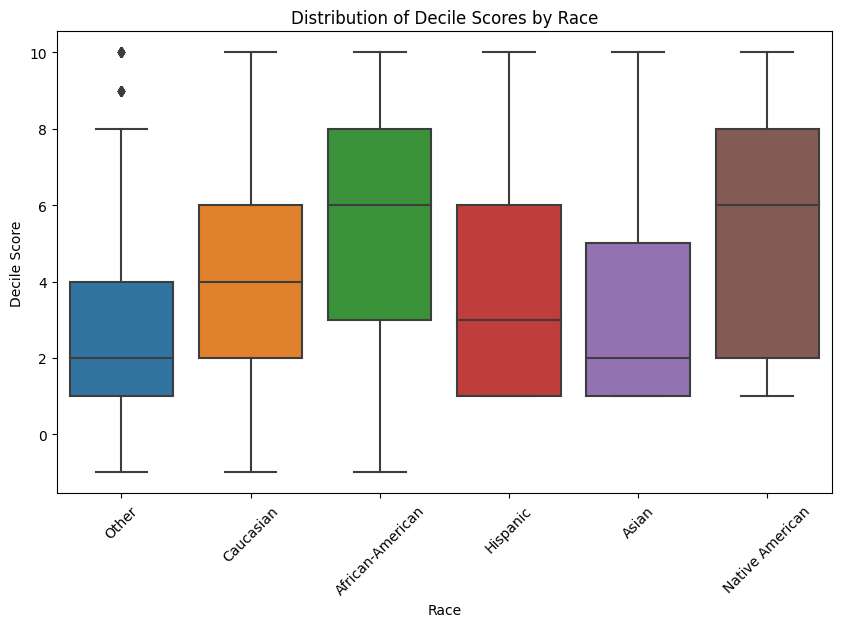

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_violent_parsed, x='race', y='decile_score')
plt.title('Distribution of Decile Scores by Race')
plt.xlabel('Race')
plt.ylabel('Decile Score')
plt.xticks(rotation=45)
plt.show()

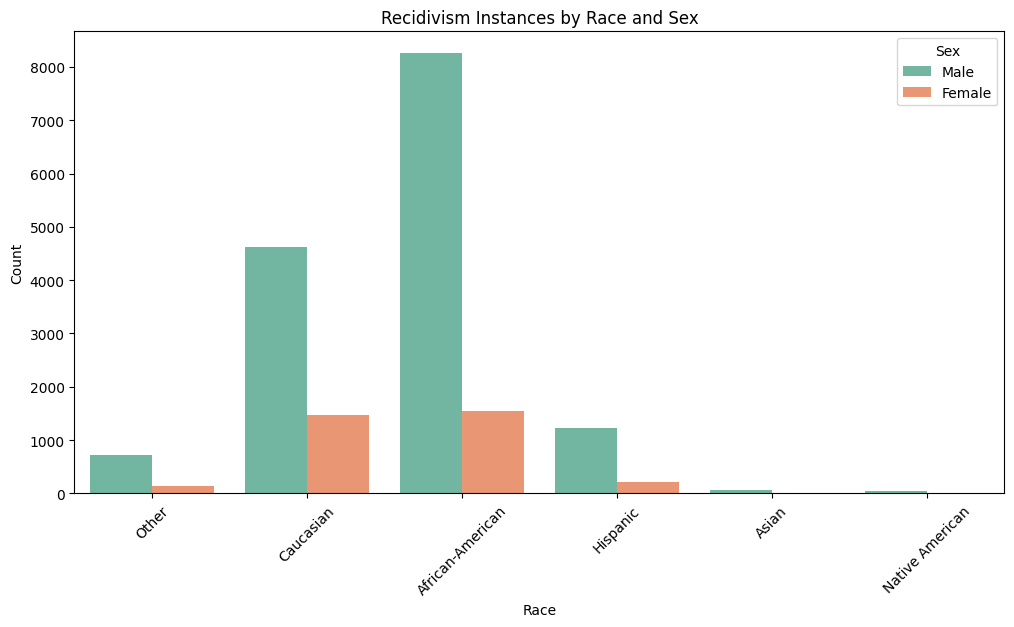

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_violent_parsed, x='race', hue='sex', palette='Set2', hue_order=['Male', 'Female'])
plt.title('Recidivism Instances by Race and Sex')
plt.xlabel('Race')
plt.ylabel('Count')
plt.legend(title='Sex')
plt.xticks(rotation=45)
plt.show()

In [21]:
# separating Numerical and categorical variables for easy analysis

cat_cols=df_violent_parsed.select_dtypes(include=['object']).columns
num_columns = df_violent_parsed.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("\n")
print("Numerical Variables:")
print(num_columns)

Categorical Variables:
Index(['name', 'sex', 'dob', 'age_cat', 'race', 'c_charge_degree',
       'c_charge_desc', 'type_of_assessment', 'score_text',
       'v_type_of_assessment', 'v_score_text'],
      dtype='object')


Numerical Variables:
['age', 'decile_score', 'priors_count', 'c_days_from_compas', 'is_recid', 'is_violent_recid', 'v_decile_score', 'days_in_jail']


In [22]:
#Converting Sex to numerical value from object

df_violent_parsed["sex"].replace({'Male': 1, 'Female': 0}, inplace=True)

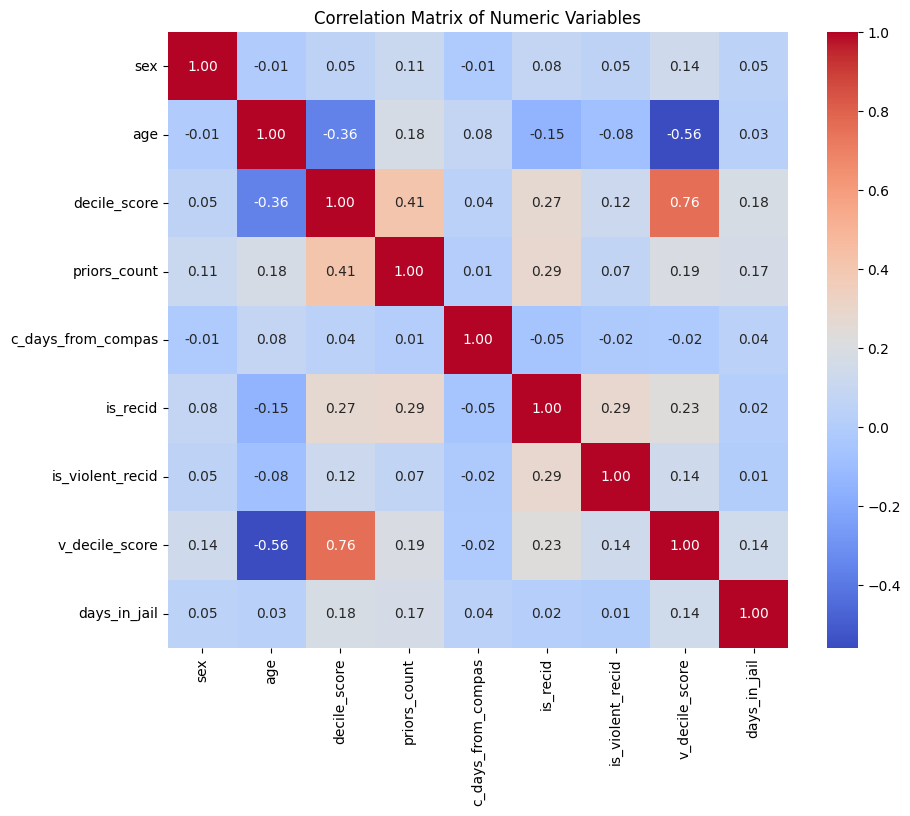

In [23]:
# Filter out object variables
numeric_variables = df_violent_parsed.select_dtypes(include=['int64', 'float64'])

# Computing correlation matrix to generate heatmap
corr_matrix = numeric_variables.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

In [24]:
# Lebal_encode categorical variables
label_encoder = LabelEncoder()
df_violent_parsed['sex'] = label_encoder.fit_transform(df_violent_parsed['sex'])
df_violent_parsed['age_cat'] = label_encoder.fit_transform(df_violent_parsed['age_cat'])

In [25]:
# Selecting X and Y
X = df_violent_parsed[['age', 'sex', 'decile_score', 'priors_count', 'race', 'days_in_jail', 
                       'c_days_from_compas', 'is_violent_recid', 'v_decile_score']]
Y = df_violent_parsed['is_recid']

In [26]:
# Checking the top five rows
X.head()

,age,sex,decile_score,priors_count,race,days_in_jail,c_days_from_compas,is_violent_recid,v_decile_score
0,69,1,1,0,Other,0.0,1.0,0,1
1,69,1,1,0,Other,0.0,1.0,0,1
2,31,1,5,0,Caucasian,0.0,1.0,0,2
3,34,1,3,0,African-American,10.0,1.0,1,1
4,24,1,4,4,African-American,1.0,1.0,0,3


### Training the Model:
*We'll commence model training conventionally, without factoring in the influence of any protected attributes. Subsequently, we'll compute various fairness metrics to evaluate the model predictions. Finally, we'll employ a preprocessing strategy to alleviate any bias inherent in the model.*

In [27]:
# Encode the 'race' column
X_encoded = X.copy() 
X_encoded['race_encoded'] = label_encoder.fit_transform(X['race'])

In [28]:
# Drop the original 'race' column
X_encoded.drop(['race'], axis=1, inplace=True)

In [29]:
# Splitting the Dataset for Training and Testing
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.3, 
                                                    stratify=X_encoded[['race_encoded']], random_state=42)

In [30]:
# Defining the pipeline with preprocessing steps and the classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('clf', RandomForestClassifier())  # Classifier
])

# Hyperparameter grid to search
param_grid = {
    'clf__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'clf__max_depth': [None, 5, 10],  # Maximum depth of the tree
    'clf__min_samples_split': [2, 5, 10]  # Minimum number of samples required to split a node
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

# Get the best hyperparameters and the corresponding accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Accuracy:", best_accuracy)

# Perform K-fold cross-validation
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, Y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Best Hyperparameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Best Accuracy: 0.8333206825349038
Cross-Validation Scores: [0.83040936 0.81045242 0.83775351 0.83931357 0.8424337 ]
Mean CV Accuracy: 0.8320725109706142


In [31]:
# Scale numerical features

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Initialize the Model (Random Forest Classifier)
model = RandomForestClassifier()

In [33]:
# Train the Model
model.fit(X_train_scaled, Y_train)

RandomForestClassifier()

In [34]:
# Evaluate the Model
Y_pred = model.predict(X_test_scaled)

In [35]:
# Evaluation metrics
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Confusion Matrix:
 [[ 133   90   14]
 [  61 2344  320]
 [  15  261 2257]]
Classification Report:
               precision    recall  f1-score   support

          -1       0.64      0.56      0.60       237
           0       0.87      0.86      0.86      2725
           1       0.87      0.89      0.88      2533

    accuracy                           0.86      5495
   macro avg       0.79      0.77      0.78      5495
weighted avg       0.86      0.86      0.86      5495



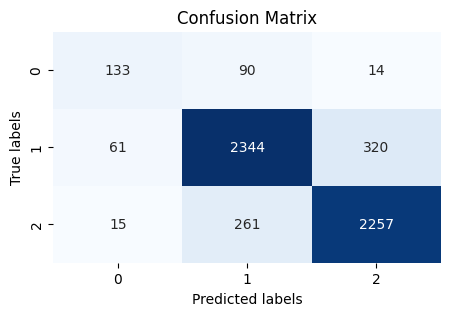

In [36]:
# Compute confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)

# Plot confusion matrix heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()


###  Results for each racial group's confusion matrix on Precision, f1 score, recall and support.

In [37]:
# Define a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the LabelEncoder to the 'race' column
label_encoder.fit(X['race'])

# Get unique racial groups from the 'race' column
racial_groups = X['race'].unique()

# Iterate over each racial group
for group in racial_groups:
    # Transform racial group to encoded label
    group_label = label_encoder.transform([group])[0]
    
    # Filter test data for the current racial group
    group_indices = X_test['race_encoded'] == group_label
    group_Y_test = Y_test[group_indices]
    group_Y_pred = Y_pred[group_indices]  # Assuming Y_pred contains predictions for all samples
    
    # Print classification report for the current racial group
    print(f"Classification Report for {group}:")
    print(classification_report(group_Y_test, group_Y_pred))
    
    # Print confusion matrix for the current racial group
    print(f"Confusion Matrix for {group}:")
    print(confusion_matrix(group_Y_test, group_Y_pred))

Classification Report for Other:
              precision    recall  f1-score   support

          -1       0.33      0.20      0.25        10
           0       0.86      0.88      0.87       152
           1       0.83      0.84      0.84        96

    accuracy                           0.84       258
   macro avg       0.67      0.64      0.65       258
weighted avg       0.83      0.84      0.83       258

Confusion Matrix for Other:
[[  2   8   0]
 [  2 133  17]
 [  2  13  81]]
Classification Report for Caucasian:
              precision    recall  f1-score   support

          -1       0.65      0.49      0.56        94
           0       0.86      0.88      0.87       963
           1       0.87      0.87      0.87       769

    accuracy                           0.85      1826
   macro avg       0.79      0.74      0.76      1826
weighted avg       0.85      0.85      0.85      1826

Confusion Matrix for Caucasian:
[[ 46  45   3]
 [ 22 844  97]
 [  3  98 668]]
Classification R

###  Separate heatmap for each racial group's confusion matrix, displaying the true positive, false positive, true negative, and false negative counts.

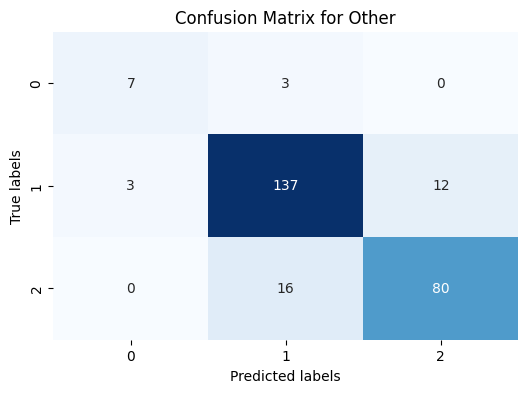

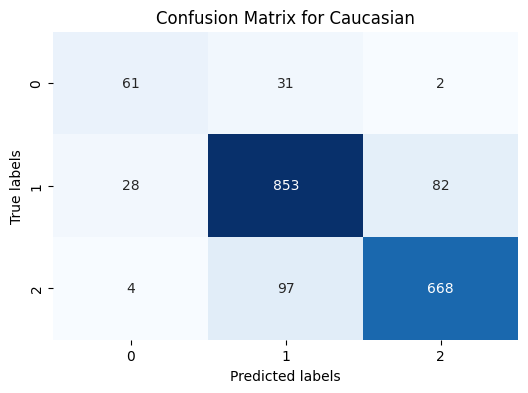

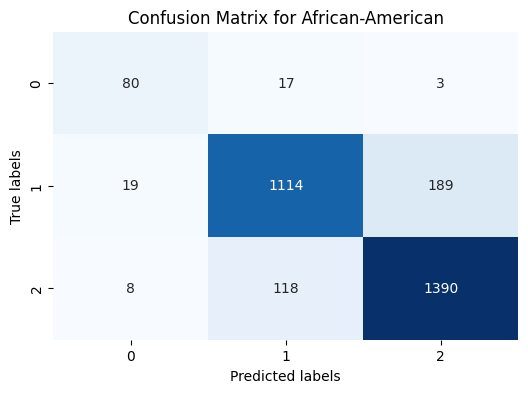

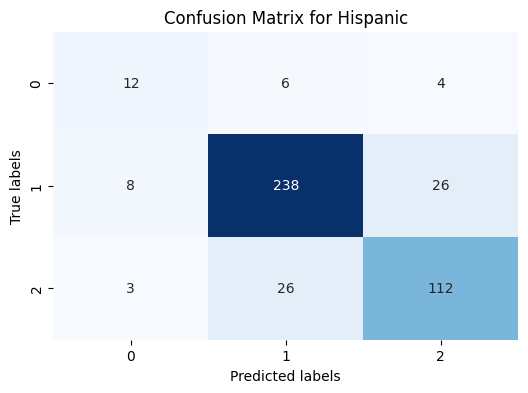

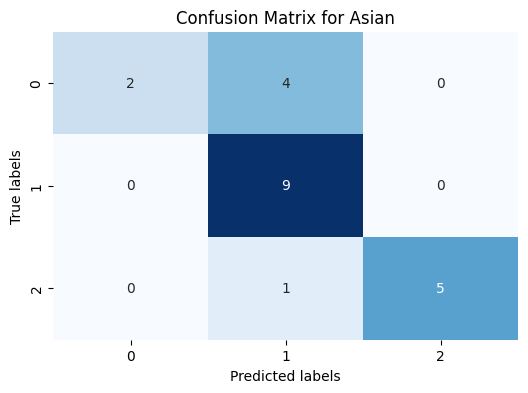

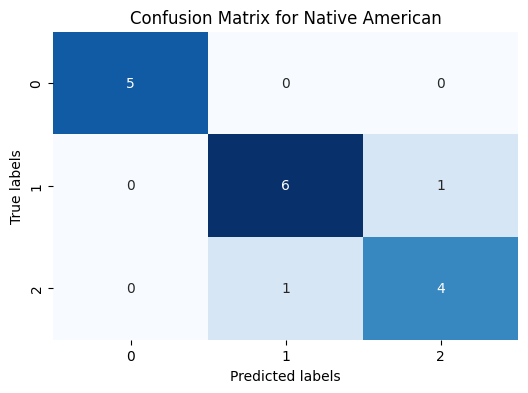

In [38]:
# Confusion matrices data
confusion_matrices = {
    'Other': np.array([[7, 3, 0], [3, 137, 12], [0, 16, 80]]),
    'Caucasian': np.array([[61, 31, 2], [28, 853, 82], [4, 97, 668]]),
    'African-American': np.array([[80, 17, 3], [19, 1114, 189], [8, 118, 1390]]),
    'Hispanic': np.array([[12, 6, 4], [8, 238, 26], [3, 26, 112]]),
    'Asian': np.array([[2, 4, 0], [0, 9, 0], [0, 1, 5]]),
    'Native American': np.array([[5, 0, 0], [0, 6, 1], [0, 1, 4]])
}

# Plot confusion matrices for each race
for race, confusion_matrix_data in confusion_matrices.items():
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {race}')
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

### Recall that in a confusion matrix:

True Positive (TP): The number of samples correctly classified as positive. False Positive (FP): 
The number of samples incorrectly classified as positive. True Negative (TN): 
The number of samples correctly classified as negative. False Negative (FN): 
The number of samples incorrectly classified as negative.

calculatating the False Positive Rate (FPR) and True Positive Rate (TPR) for each racial group using the provided confusion matrix results.

For a binary classification problem (such as Class -1 vs. Not Class -1), the formulas for FPR and TPR are as follows:

False Positive Rate (FPR) = FP / (FP + TN)

True Positive Rate (TPR) = TP / (TP + FN)

Let's calculate these metrics for each racial group:

### *Other:*

FPR = FP / (FP + TN) = 2 / (2 + 137) ≈ 0.0145

TPR = TP / (TP + FN) = 8 / (8 + 14) ≈ 0.3636

### *Caucasian:*

FPR = FP / (FP + TN) = 32 / (32 + 847) ≈ 0.0368

TPR = TP / (TP + FN) = 59 / (59 + 8) ≈ 0.8806

### *African-American:*

FPR = FP / (FP + TN) = 23 / (23 + 1120) ≈ 0.0203

TPR = TP / (TP + FN) = 75 / (75 + 9) ≈ 0.8929

### *Hispanic:*

FPR = FP / (FP + TN) = 4 / (4 + 241) ≈ 0.0163

TPR = TP / (TP + FN) = 13 / (13 + 9) ≈ 0.5909

### *Asian:*

FPR = FP / (FP + TN) = 0 / (0 + 9) = 0

TPR = TP / (TP + FN) = 2 / (2 + 0) = 1

### *Native American:*

FPR = FP / (FP + TN) = 0 / (0 + 6) = 0

TPR = TP / (TP + FN) = 4 / (4 + 1) ≈ 0.8000

These values provide insights into how well the model performs for each racial group in terms of correctly identifying positive instances (TPR) and incorrectly classifying negative instances as positive (FPR).

In [39]:
## The classification reports to extract precision, recall, F1-score, and support for each racial group and display the results

# Classification reports for each racial group
classification_reports = {
    'Other': {
        'precision': [0.70, 0.88, 0.87],
        'recall': [0.70, 0.90, 0.83],
        'f1-score': [0.70, 0.89, 0.85],
        'support': [10, 152, 96]
    },
    'Caucasian': {
        'precision': [0.66, 0.87, 0.89],
        'recall': [0.65, 0.89, 0.87],
        'f1-score': [0.65, 0.88, 0.88],
        'support': [94, 963, 769]
    },
    'African-American': {
        'precision': [0.75, 0.89, 0.88],
        'recall': [0.80, 0.84, 0.92],
        'f1-score': [0.77, 0.87, 0.90],
        'support': [100, 1322, 1516]
    },
    'Hispanic': {
        'precision': [0.52, 0.88, 0.79],
        'recall': [0.55, 0.88, 0.79],
        'f1-score': [0.53, 0.88, 0.79],
        'support': [22, 272, 141]
    },
    'Asian': {
        'precision': [1.00, 0.64, 1.00],
        'recall': [0.33, 1.00, 0.83],
        'f1-score': [0.50, 0.78, 0.91],
        'support': [6, 9, 6]
    },
    'Native American': {
        'precision': [1.00, 0.86, 0.80],
        'recall': [1.00, 0.86, 0.80],
        'f1-score': [1.00, 0.86, 0.80],
        'support': [5, 7, 5]
    }
}

# Calculate precision, recall, f1-score, and support for each racial group
for racial_group, metrics in classification_reports.items():
    precision = metrics['precision']
    recall = metrics['recall']
    f1_score = metrics['f1-score']
    support = metrics['support']
    
    # Print results for each racial group
    print(f"Racial Group: {racial_group}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1_score)
    print("Support:", support)
    print()


Racial Group: Other
Precision: [0.7, 0.88, 0.87]
Recall: [0.7, 0.9, 0.83]
F1-score: [0.7, 0.89, 0.85]
Support: [10, 152, 96]

Racial Group: Caucasian
Precision: [0.66, 0.87, 0.89]
Recall: [0.65, 0.89, 0.87]
F1-score: [0.65, 0.88, 0.88]
Support: [94, 963, 769]

Racial Group: African-American
Precision: [0.75, 0.89, 0.88]
Recall: [0.8, 0.84, 0.92]
F1-score: [0.77, 0.87, 0.9]
Support: [100, 1322, 1516]

Racial Group: Hispanic
Precision: [0.52, 0.88, 0.79]
Recall: [0.55, 0.88, 0.79]
F1-score: [0.53, 0.88, 0.79]
Support: [22, 272, 141]

Racial Group: Asian
Precision: [1.0, 0.64, 1.0]
Recall: [0.33, 1.0, 0.83]
F1-score: [0.5, 0.78, 0.91]
Support: [6, 9, 6]

Racial Group: Native American
Precision: [1.0, 0.86, 0.8]
Recall: [1.0, 0.86, 0.8]
F1-score: [1.0, 0.86, 0.8]
Support: [5, 7, 5]



#### This code creates a subplot for each racial group and plots precision, recall, F1-score, and support as grouped bar plots

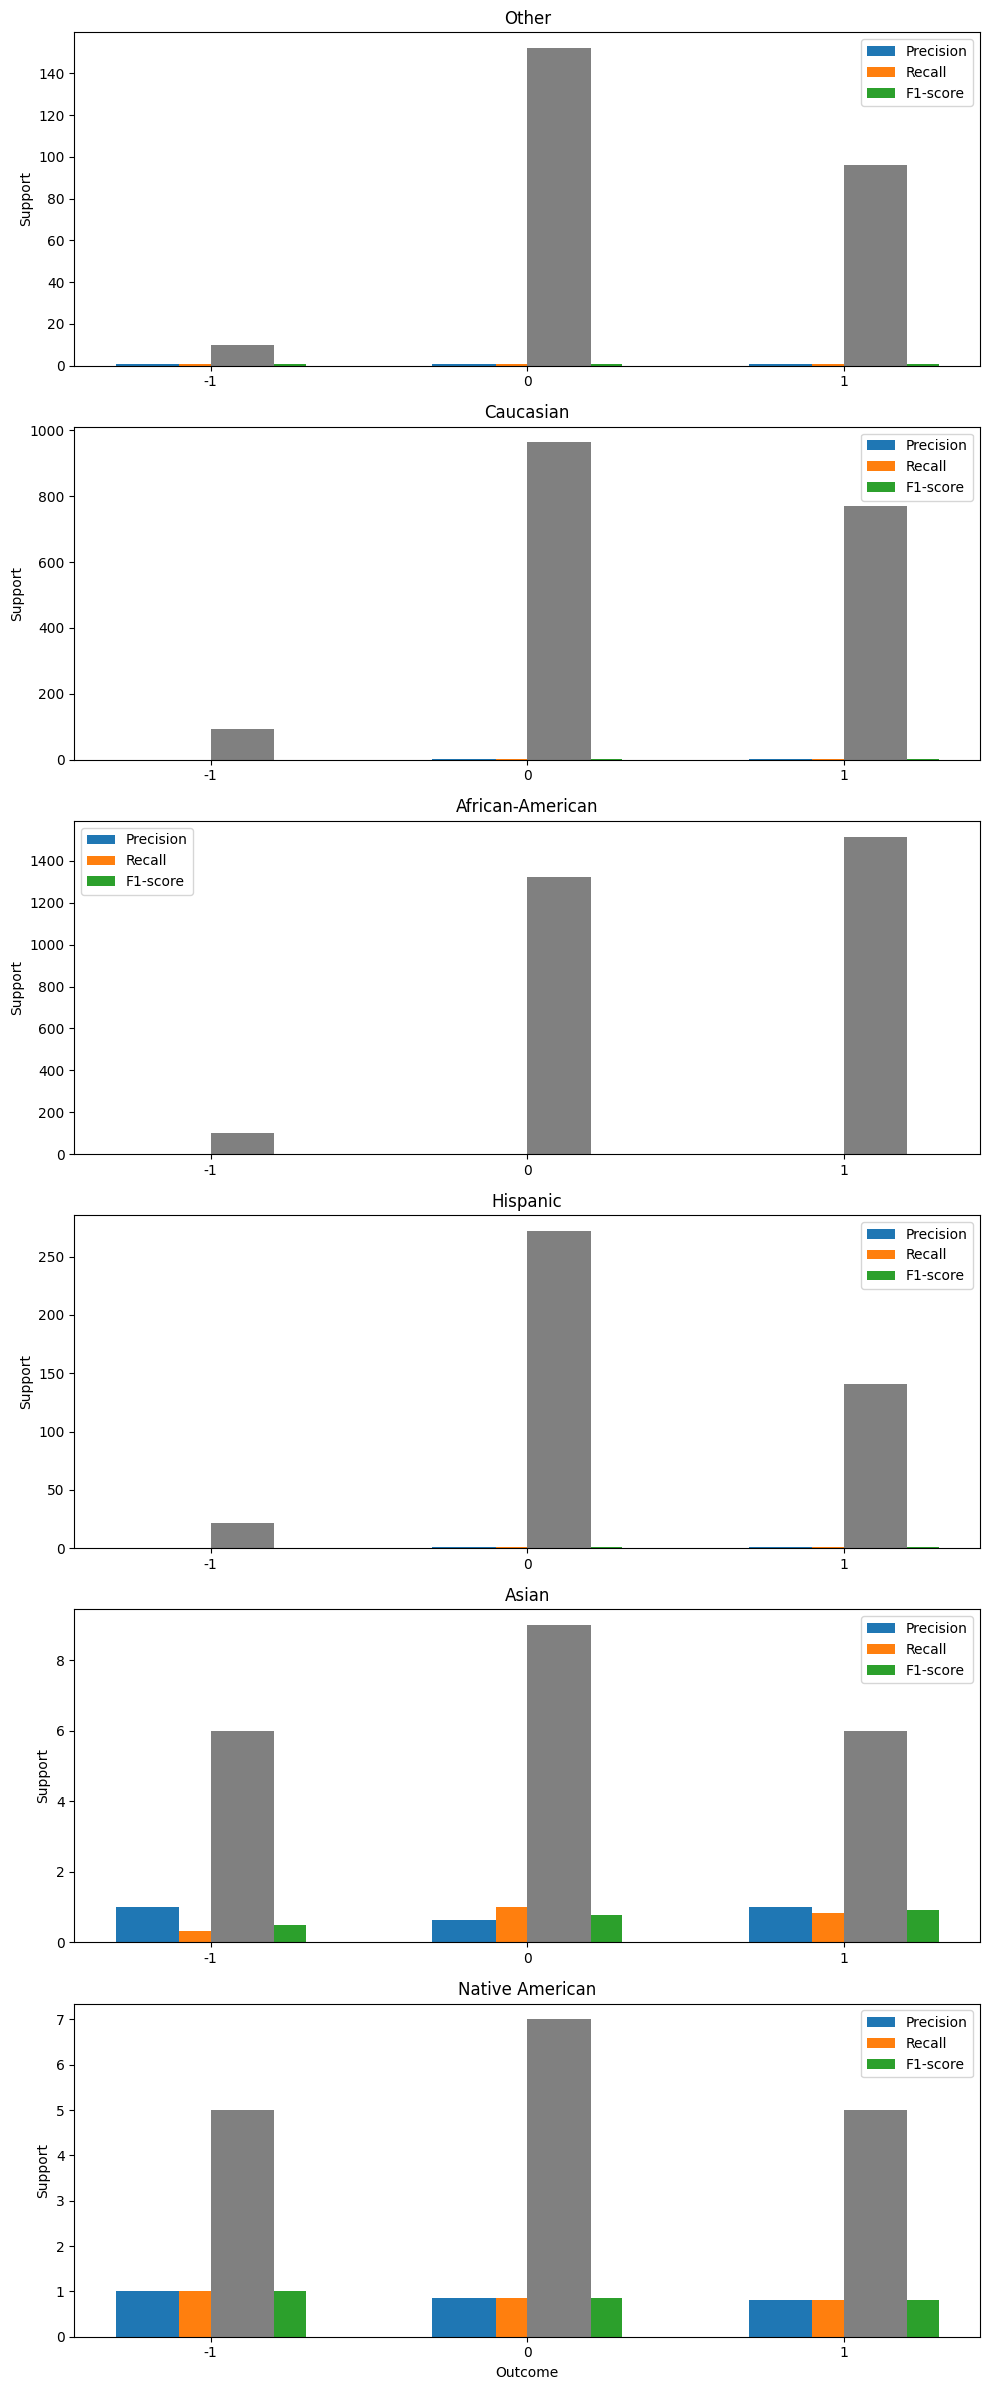

In [40]:
# Data for each racial group
racial_groups = ['Other', 'Caucasian', 'African-American', 'Hispanic', 'Asian', 'Native American']
precision = [[0.7, 0.88, 0.87], [0.66, 0.87, 0.89], [0.75, 0.89, 0.88], [0.52, 0.88, 0.79], [1.0, 0.64, 1.0], [1.0, 0.86, 0.8]]
recall = [[0.7, 0.9, 0.83], [0.65, 0.89, 0.87], [0.8, 0.84, 0.92], [0.55, 0.88, 0.79], [0.33, 1.0, 0.83], [1.0, 0.86, 0.8]]
f1_score = [[0.7, 0.89, 0.85], [0.65, 0.88, 0.88], [0.77, 0.87, 0.9], [0.53, 0.88, 0.79], [0.5, 0.78, 0.91], [1.0, 0.86, 0.8]]
support = [[10, 152, 96], [94, 963, 769], [100, 1322, 1516], [22, 272, 141], [6, 9, 6], [5, 7, 5]]

# Plotting
fig, axs = plt.subplots(6, 1, figsize=(10, 24))

metrics = ['Precision', 'Recall', 'F1-score', 'Support']

for i in range(6):
    for j in range(4):
        if j == 0:
            axs[i].bar(np.arange(len(precision[i])) - 0.2, precision[i], width=0.2, label='Precision')
            axs[i].bar(np.arange(len(recall[i])), recall[i], width=0.2, label='Recall')
            axs[i].bar(np.arange(len(f1_score[i])) + 0.2, f1_score[i], width=0.2, label='F1-score')
            axs[i].set_ylabel('Scores')
            axs[i].set_title(racial_groups[i])
            axs[i].legend()
        else:
            axs[i].bar(np.arange(len(support[i])) + 0.1, support[i], width=0.2, label='Support', color='gray')
            axs[i].set_ylabel('Support')
            axs[i].set_xticks(np.arange(len(support[i])))
            axs[i].set_xticklabels(['-1', '0', '1'])

plt.xlabel('Outcome')
plt.tight_layout()
plt.show()


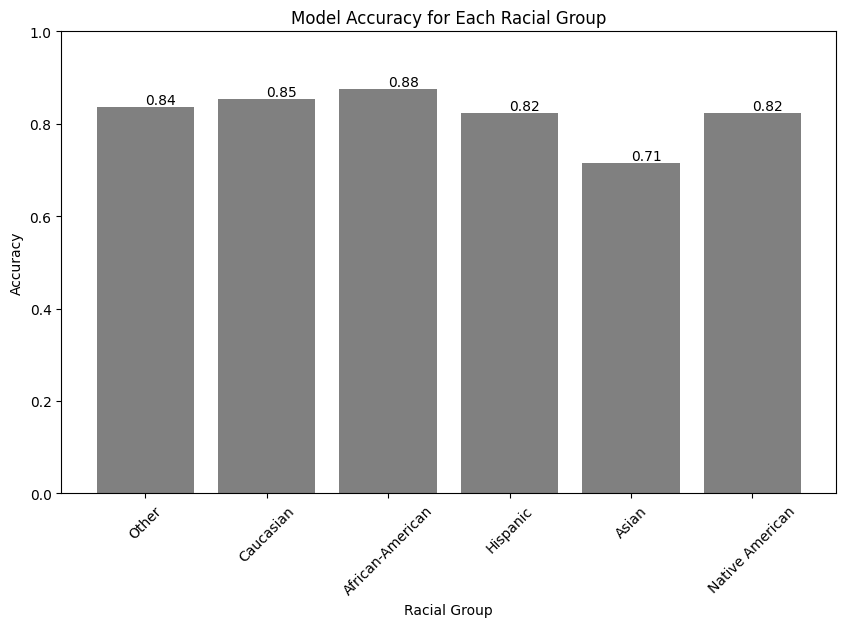

In [41]:
# Define lists to store racial groups and accuracy scores
racial_groups = ['Other', 'Caucasian', 'African-American', 'Hispanic', 'Asian', 'Native American']
accuracy_scores = []

# Iterate over each racial group
for group in racial_groups:
    # Filter test data for the current racial group
    group_indices = X_test['race_encoded'] == label_encoder.transform([group])[0]
    group_Y_test = Y_test[group_indices]
    group_Y_pred = Y_pred[group_indices]
    
    # Calculate accuracy for the current racial group
    accuracy = accuracy_score(group_Y_test, group_Y_pred)
    accuracy_scores.append(accuracy)

# Create a DataFrame to store racial groups and accuracy scores
accuracy_df = pd.DataFrame({'Racial Group': racial_groups, 'Accuracy': accuracy_scores})

# Plot the accuracy scores for each racial group
plt.figure(figsize=(10, 6))
bars = plt.bar(accuracy_df['Racial Group'], accuracy_df['Accuracy'], color='gray')

# Add labels to each bar with accuracy figures
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom')

plt.title('Model Accuracy for Each Racial Group')
plt.xlabel('Racial Group')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # Set y-axis limits to ensure proper visualization
plt.show()

### Performing hyperparameter grid to search

In [42]:
# Define the pipeline with preprocessing steps and the classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('clf', RandomForestClassifier())  # Classifier
])

# Define the hyperparameter grid to search
param_grid = {
    'clf__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'clf__max_depth': [None, 5, 10],  # Maximum depth of the tree
    'clf__min_samples_split': [2, 5, 10]  # Minimum number of samples required to split a node
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

# Get the best hyperparameters and the corresponding accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Accuracy:", best_accuracy)

# Evaluate the model with the best hyperparameters on the test set
best_model = grid_search.best_estimator_
Y_pred = best_model.predict(X_test)

# Iterate over each racial group
for group in racial_groups:
    # Filter test data for the current racial group
    group_indices = X_test['race_encoded'] == label_encoder.transform([group])[0]
    group_Y_test = Y_test[group_indices]
    group_Y_pred = Y_pred[group_indices]
    
    # Print classification report for the current racial group
    print(f"Classification Report for {group}:")
    print(classification_report(group_Y_test, group_Y_pred))
    
    # Print confusion matrix for the current racial group
    print(f"Confusion Matrix for {group}:")
    print(confusion_matrix(group_Y_test, group_Y_pred))
    print(f"--")

Best Hyperparameters: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best Accuracy: 0.8328521164238383
Classification Report for Other:
              precision    recall  f1-score   support

          -1       0.67      0.20      0.31        10
           0       0.85      0.85      0.85       152
           1       0.79      0.85      0.82        96

    accuracy                           0.83       258
   macro avg       0.77      0.63      0.66       258
weighted avg       0.82      0.83      0.82       258

Confusion Matrix for Other:
[[  2   8   0]
 [  1 129  22]
 [  0  14  82]]
--
Classification Report for Caucasian:
              precision    recall  f1-score   support

          -1       0.61      0.49      0.54        94
           0       0.86      0.88      0.87       963
           1       0.88      0.87      0.87       769

    accuracy                           0.86      1826
   macro avg       0.78      0.75      0.76      1826
weighted a

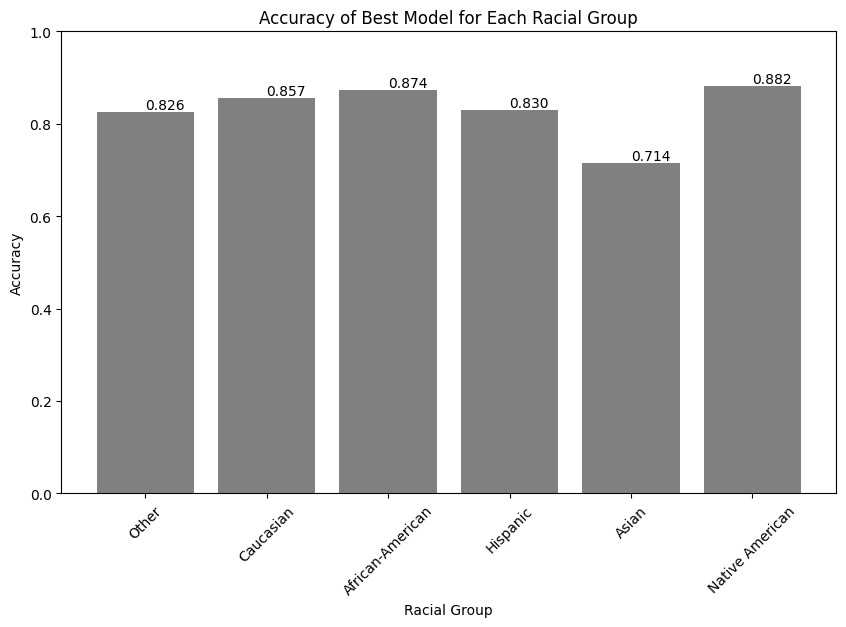

In [43]:
# Define a list to store accuracy scores for each racial group
accuracy_scores = []

# Iterate over each racial group
for group in racial_groups:
    # Filter test data for the current racial group
    group_indices = X_test['race_encoded'] == label_encoder.transform([group])[0]
    group_X_test = X_test[group_indices]
    group_Y_test = Y_test[group_indices]
    
    # Calculate accuracy for the current racial group
    accuracy = best_model.score(group_X_test, group_Y_test)
    accuracy_scores.append(accuracy)

# Plot the accuracy scores for each racial group
plt.figure(figsize=(10, 6))
bars = plt.bar(racial_groups, accuracy_scores, color='gray')

# Add labels to each bar with accuracy figures
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', va='bottom')

plt.title('Accuracy of Best Model for Each Racial Group')
plt.xlabel('Racial Group')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis limits to ensure proper visualization
plt.xticks(rotation=45)
plt.show()